# Laboratorio 7 - Spark MLlib
CC3066 - Data Science  

## Análisis exploratorio avanzado y segmentación

### Integrantes

- María José Girón Isidro
- Leonardo Dufrey Mejía Mejía
- Mia Alejandra Fuentes Mérida

---

## Objetivo

En este notebook se realiza la preparación, análisis exploratorio y
segmentación de los datos de Personas de la Encuesta Nacional de Empleo
e Ingresos Continua (ENEIC).

Para el desarrollo se utilizan los cuatro trimestres correspondientes
al año 2025. El primer trimestre de 2026 se mantiene separado para la
evaluación final.

In [1]:
import os
import math
import pandas as pd
import numpy as np
import openpyxl
import gc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import matplotlib.pyplot as plt

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Laboratorio7-ENEIC")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Versión de Spark:", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/28 01:52:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Versión de Spark: 3.5.1


In [3]:
print("Estoy trabajando en:")
print(os.getcwd())
print("Archivos disponibles:")
print(os.listdir("."))
print(os.listdir("./data"))

Estoy trabajando en:
/opt/app/work
Archivos disponibles:
['.git', '.gitignore', 'Base-de-datos-Personas-ENEIC-IV-2025.zip', 'data', 'Laboratorio7.ipynb', 'README.md']
['Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'diccionarios', 'parquet', 'Personas-ENEIC-T2-2025.xlsx', 'Personas_ENEIC_T1_2025.xlsx']


## 1. Carga, armonización y calidad de datos

In [4]:
DATA_DIR = "./data"

ARCHIVOS = {
    "2025T1": {
        "ruta": f"{DATA_DIR}/Personas_ENEIC_T1_2025.xlsx",
        "anio": 2025,
        "trimestre": 1
    },
    "2025T2": {
        "ruta": f"{DATA_DIR}/Personas-ENEIC-T2-2025.xlsx",
        "anio": 2025,
        "trimestre": 2
    },
    "2025T3": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
        "anio": 2025,
        "trimestre": 3
    },
    "2025T4": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
        "anio": 2025,
        "trimestre": 4
    },
    "2026T1": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
        "anio": 2026,
        "trimestre": 1
    }
}

for periodo, info in ARCHIVOS.items():
    print(periodo, "->", os.path.exists(info["ruta"]))

2025T1 -> True
2025T2 -> True
2025T3 -> True
2025T4 -> True
2026T1 -> True


In [5]:
COLUMNAS_REQUERIDAS = [
    "P05D01",       # salario mensual
    "P02A03",       # edad
    "P05C07A",      # antigüedad años
    "P05C07B",      # antigüedad meses
    "P05H01A",      # horas semanales
    "P03A03A",      # nivel educativo
    "P05C16",       # categoría ocupacional
    "DOMINIO",      # dominio
    "OCUPADOS",     # condición de ocupado
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

RENOMBRES = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado"
}

In [6]:
for periodo, info in ARCHIVOS.items():

    encabezado = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        nrows=0
    )

    columnas = list(encabezado.columns)

    faltantes = [
        col for col in COLUMNAS_REQUERIDAS
        if col not in columnas
    ]

    print(f"\n{periodo}")
    print(f"Columnas totales: {len(columnas)}")
    print(f"Columnas requeridas faltantes: {faltantes}")


2025T1
Columnas totales: 270
Columnas requeridas faltantes: []

2025T2
Columnas totales: 270
Columnas requeridas faltantes: []

2025T3
Columnas totales: 270
Columnas requeridas faltantes: []

2025T4
Columnas totales: 302
Columnas requeridas faltantes: []



2026T1
Columnas totales: 270
Columnas requeridas faltantes: []


In [7]:
PARQUET_DIR = "./data/parquet"

os.makedirs(PARQUET_DIR, exist_ok=True)

print("Directorio creado:", PARQUET_DIR)

Directorio creado: ./data/parquet


In [8]:
ruta_t1 = ARCHIVOS["2025T1"]["ruta"]

pdf_t1 = pd.read_excel(
    ruta_t1,
    engine="openpyxl",
    usecols=COLUMNAS_REQUERIDAS
)

print("Dimensiones:", pdf_t1.shape)
display(pdf_t1.head())

Dimensiones: (51588, 14)


,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
pdf_t1.info()


<class 'pandas.DataFrame'>
RangeIndex: 51588 entries, 0 to 51587
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ANIO         51588 non-null  int64  
 1   TRIMESTRE    51588 non-null  int64  
 2   DOMINIO      51588 non-null  int64  
 3   NUM_HOGAR    51588 non-null  int64  
 4   FACTOR       51588 non-null  int64  
 5   NUM_PERSONA  51588 non-null  int64  
 6   P02A03       51588 non-null  int64  
 7   P03A03A      44660 non-null  float64
 8   P05C07A      22273 non-null  float64
 9   P05C07B      22273 non-null  float64
 10  P05C16       22273 non-null  float64
 11  P05D01       13419 non-null  float64
 12  P05H01A      22273 non-null  float64
 13  OCUPADOS     22273 non-null  float64
dtypes: float64(7), int64(7)
memory usage: 5.5 MB


In [10]:
display(pdf_t1.head(10))

,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2025,2,2,5636,580,4,22,4.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2025,2,2,5636,580,2,41,2.0,0.0,3.0,4.0,800.0,25.0,1.0
7,2025,2,2,5636,580,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025,2,2,5636,580,1,45,2.0,0.0,1.0,7.0,NaN,25.0,1.0
9,2025,2,2,5636,580,3,20,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
for columna in COLUMNAS_REQUERIDAS:
    print(f"\n--- {columna} ---")
    print("Tipo:", pdf_t1[columna].dtype)
    print("Ejemplos:", pdf_t1[columna].dropna().unique()[:10])


--- P05D01 ---
Tipo: float64
Ejemplos: [7000.  800. 2300. 3000. 1600. 3400. 2500. 3800.  600. 1920.]

--- P02A03 ---
Tipo: int64
Ejemplos: [14 42  9 11 22 41  0 45 20 31]

--- P05C07A ---
Tipo: float64
Ejemplos: [23. 20.  0.  5.  6. 52.  1. 35. 25.  3.]

--- P05C07B ---
Tipo: float64
Ejemplos: [ 0.  3.  1.  6.  2.  5.  9. 11. 10.  7.]

--- P05H01A ---
Tipo: float64
Ejemplos: [35.  1. 25. 21. 36. 20. 24. 63. 42. 77.]

--- P03A03A ---
Tipo: float64
Ejemplos: [3. 5. 2. 4. 0. 1. 6. 7.]

--- P05C16 ---
Tipo: float64
Ejemplos: [6. 1. 4. 7. 5. 3. 2. 9. 8.]

--- DOMINIO ---
Tipo: int64
Ejemplos: [2 3 1]

--- OCUPADOS ---
Tipo: float64
Ejemplos: [1.]

--- NUM_HOGAR ---
Tipo: int64
Ejemplos: [13796  5636  8825 13797 13798  2713  9465  5052  8784 13799]

--- NUM_PERSONA ---
Tipo: int64
Ejemplos: [ 3  1  2  5  4  7  6  9  8 10]

--- FACTOR ---
Tipo: int64
Ejemplos: [338 580 562 216 552 181  68 620 200 686]

--- ANIO ---
Tipo: int64
Ejemplos: [2025]

--- TRIMESTRE ---
Tipo: int64
Ejemplos: [2]


In [12]:
print(pdf_t1["ANIO"].value_counts(dropna=False))

print(pdf_t1["TRIMESTRE"].value_counts(dropna=False))

ANIO
2025    51588
Name: count, dtype: int64
TRIMESTRE
2    51588
Name: count, dtype: int64


In [13]:
COLUMNAS_NUMERICAS = [
    "P05D01",
    "P02A03",
    "P05C07A",
    "P05C07B",
    "P05H01A",
    "OCUPADOS",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

COLUMNAS_CATEGORICAS = [
    "P03A03A",
    "P05C16",
    "DOMINIO",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

In [14]:
def cargar_y_armonizar_excel(periodo, info):

    print(f"Procesando {periodo}...")

    # Leer solamente las columnas necesarias
    pdf = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        usecols=COLUMNAS_REQUERIDAS
    )

    registros_originales = len(pdf)

    # Homologar variables numéricas
    for col in COLUMNAS_NUMERICAS:
        pdf[col] = pd.to_numeric(
            pdf[col],
            errors="coerce"
        )

    # Homologar códigos categóricos
    for col in COLUMNAS_CATEGORICAS:

        pdf[col] = pdf[col].astype("string")

        # Ejemplo: "1.0" -> "1"
        pdf[col] = pdf[col].str.replace(
            r"\.0$",
            "",
            regex=True
        )

    # Renombrar variables analíticas
    pdf = pdf.rename(columns=RENOMBRES)

    # Variables de trazabilidad
    pdf["archivo_origen"] = os.path.basename(info["ruta"])
    pdf["periodo_archivo"] = periodo
    pdf["anio_archivo"] = int(info["anio"])
    pdf["trimestre_calendario"] = int(info["trimestre"])

    print(
        f"{periodo}: "
        f"{registros_originales:,} registros"
    )

    return pdf

In [15]:
prueba_t1 = cargar_y_armonizar_excel(
    "2025T1",
    ARCHIVOS["2025T1"]
)

print(prueba_t1.shape)

display(prueba_t1.head())

Procesando 2025T1...


2025T1: 51,588 registros
(51588, 18)


,ANIO,TRIMESTRE,dominio,NUM_HOGAR,FACTOR,NUM_PERSONA,edad,nivel_educativo,antiguedad_anios,antiguedad_meses,categoria_ocupacional,salario_mensual,horas_semanales,ocupado,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,2,13796,338,3,14,3,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,2,13796,338,1,42,5,23.0,0.0,6,NaN,35.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,2,13796,338,2,42,5,20.0,0.0,1,7000.0,1.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,2,13796,338,5,9,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,2,13796,338,4,11,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [16]:
display(
    prueba_t1[
        [
            "ANIO",
            "TRIMESTRE",
            "archivo_origen",
            "periodo_archivo",
            "anio_archivo",
            "trimestre_calendario"
        ]
    ].head()
)

,ANIO,TRIMESTRE,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [17]:
conteos_originales = {}

for periodo, info in ARCHIVOS.items():

    print("\n" + "=" * 50)
    print(f"INICIANDO {periodo}")
    print("=" * 50)

    # 1. Excel -> pandas
    pdf = cargar_y_armonizar_excel(periodo, info)

    conteos_originales[periodo] = len(pdf)

    # 2. Cambiar pd.NA / NaN por None donde corresponda
    pdf_spark = pdf.astype(object).where(pd.notnull(pdf), None)

    # 3. pandas -> Spark
    sdf = spark.createDataFrame(pdf_spark)

    # 4. Guardar como Parquet
    ruta_salida = f"{PARQUET_DIR}/{periodo}"

    (
        sdf.write
        .mode("overwrite")
        .parquet(ruta_salida)
    )

    print(f"Parquet guardado en: {ruta_salida}")
    print(f"Registros: {sdf.count():,}")

    # 5. Liberar memoria
    del pdf
    del pdf_spark
    del sdf

    gc.collect()

print("\nConversión terminada.")


INICIANDO 2025T1
Procesando 2025T1...


2025T1: 51,588 registros


Parquet guardado en: ./data/parquet/2025T1


Registros: 51,588

INICIANDO 2025T2
Procesando 2025T2...


2025T2: 51,167 registros


...

Parquet guardado en: ./data/parquet/2025T4


Registros: 49,338

INICIANDO 2026T1
Procesando 2026T1...


2026T1: 49,843 registros


Parquet guardado en: ./data/parquet/2026T1


Registros: 49,843

Conversión terminada.


In [18]:
print("REGISTROS ORIGINALES")
print("-" * 35)

for periodo, cantidad in conteos_originales.items():
    print(f"{periodo}: {cantidad:,}")

REGISTROS ORIGINALES
-----------------------------------
2025T1: 51,588
2025T2: 51,167
2025T3: 51,583
2025T4: 49,338
2026T1: 49,843


In [19]:
df_2025_t1 = spark.read.parquet(f"{PARQUET_DIR}/2025T1")
df_2025_t2 = spark.read.parquet(f"{PARQUET_DIR}/2025T2")
df_2025_t3 = spark.read.parquet(f"{PARQUET_DIR}/2025T3")
df_2025_t4 = spark.read.parquet(f"{PARQUET_DIR}/2025T4")

df_2026 = spark.read.parquet(f"{PARQUET_DIR}/2026T1")

In [20]:
df_2025 = (
    df_2025_t1
    .unionByName(df_2025_t2)
    .unionByName(df_2025_t3)
    .unionByName(df_2025_t4)
)

In [21]:
total_2025 = df_2025.count()

print(f"Total registros 2025: {total_2025:,}")

Total registros 2025: 203,676


In [22]:
df_2025.printSchema()

root
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- dominio: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)



In [23]:
df_2025.show(5, truncate=False)

+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|ANIO|TRIMESTRE|dominio|NUM_HOGAR|FACTOR|NUM_PERSONA|edad|nivel_educativo|antiguedad_anios|antiguedad_meses|categoria_ocupacional|salario_mensual|horas_semanales|ocupado|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|
+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|2025|2        |2      |12647    |519   |1          |80  |2              |NULL            |NULL            |NULL                 |NULL           |NULL           |NULL   |Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |
|202

In [24]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "anio_archivo",
        "trimestre_calendario"
    )
    .count()
    .orderBy("periodo_archivo")
    .show()
)

+---------------+------------+--------------------+-----+
|periodo_archivo|anio_archivo|trimestre_calendario|count|
+---------------+------------+--------------------+-----+
|         2025T1|        2025|                   1|51588|
|         2025T2|        2025|                   2|51167|
|         2025T3|        2025|                   3|51583|
|         2025T4|        2025|                   4|49338|
+---------------+------------+--------------------+-----+



In [25]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .count()
    .orderBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .show()
)

+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|        2|51588|
|         2025T2|        2|  175|
|         2025T2|        3|50992|
|         2025T3|        4|51583|
|         2025T4|        5|49338|
+---------------+---------+-----+



### Identificación del período

Se conservó la variable `TRIMESTRE` tal como aparece en las bases
originales. Sin embargo, esta variable no se utilizó directamente para
identificar el trimestre calendario.

En su lugar, se construyeron las variables `periodo_archivo`,
`anio_archivo` y `trimestre_calendario` utilizando el archivo de
procedencia de cada observación.

Esta decisión evita asumir que los códigos originales de `TRIMESTRE`
corresponden directamente al trimestre calendario y permite mantener
trazabilidad respecto de la fuente original.

In [26]:
columnas_analisis = [
    "salario_mensual",
    "edad",
    "antiguedad_anios",
    "antiguedad_meses",
    "horas_semanales",
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio",
    "ocupado",
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

total = df_2025.count()

faltantes_expr = []

for col in columnas_analisis:
    faltantes_expr.append(
        F.sum(
            F.when(F.col(col).isNull(), 1).otherwise(0)
        ).alias(col)
    )

fila_faltantes = df_2025.agg(*faltantes_expr).first()

datos_faltantes = []

for col in columnas_analisis:
    n = fila_faltantes[col]

    datos_faltantes.append(
        (
            col,
            n,
            round(n / total * 100, 2)
        )
    )

df_faltantes = spark.createDataFrame(
    datos_faltantes,
    ["variable", "faltantes", "porcentaje"]
)

df_faltantes.show(30, truncate=False)

+---------------------+---------+----------+
|variable             |faltantes|porcentaje|
+---------------------+---------+----------+
|salario_mensual      |150651   |73.97     |
|edad                 |0        |0.0       |
|antiguedad_anios     |115454   |56.69     |
|antiguedad_meses     |115454   |56.69     |
|horas_semanales      |115454   |56.69     |
|nivel_educativo      |26344    |12.93     |
|categoria_ocupacional|115454   |56.69     |
|dominio              |0        |0.0       |
|ocupado              |115454   |56.69     |
|NUM_HOGAR            |0        |0.0       |
|NUM_PERSONA          |0        |0.0       |
|FACTOR               |0        |0.0       |
|ANIO                 |0        |0.0       |
|TRIMESTRE            |0        |0.0       |
+---------------------+---------+----------+



In [27]:
claves = [
    "periodo_archivo",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

duplicados = (
    df_2025
    .groupBy(*claves)
    .count()
    .filter(F.col("count") > 1)
)

cantidad_claves_duplicadas = duplicados.count()

print(
    "Cantidad de claves con más de un registro:",
    cantidad_claves_duplicadas
)

Cantidad de claves con más de un registro: 0


In [28]:
duplicados.orderBy(F.desc("count")).show(
    20,
    truncate=False
)

+---------------+---------+-----------+-----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



In [29]:
df_2025_preparacion = df_2025.withColumn(
    "antiguedad",
    F.col("antiguedad_anios")
    + F.col("antiguedad_meses") / F.lit(12.0)
)

In [30]:
df_2025_preparacion.select(
    "antiguedad_anios",
    "antiguedad_meses",
    "antiguedad"
).show(10)

+----------------+----------------+----------+
|antiguedad_anios|antiguedad_meses|antiguedad|
+----------------+----------------+----------+
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|            NULL|            NULL|      NULL|
|             4.0|             0.0|       4.0|
|            NULL|            NULL|      NULL|
+----------------+----------------+----------+
only showing top 10 rows



In [31]:
def aplicar_filtro_y_contar(df, nombre, condicion):
    antes = df.count()

    nuevo_df = df.filter(condicion)

    despues = nuevo_df.count()
    excluidos = antes - despues

    return nuevo_df, {
        "paso": nombre,
        "antes": antes,
        "excluidos": excluidos,
        "despues": despues
    }

In [32]:
df_limpio = df_2025_preparacion

auditoria_filtros = []

In [33]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Edad finita y >= 15",
    F.col("edad").isNotNull()
    & (~F.isnan(F.col("edad").cast("double")))
    & (F.col("edad") >= 15)
)

auditoria_filtros.append(resultado)

In [34]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "OCUPADOS = 1",
    F.col("ocupado") == 1
)

auditoria_filtros.append(resultado)

In [35]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "P05C16 en {1,2,3,4}",
    F.col("categoria_ocupacional").isin(
        "1", "2", "3", "4"
    )
)

auditoria_filtros.append(resultado)

In [36]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Salario finito y > 0",
    F.col("salario_mensual").isNotNull()
    & (~F.isnan("salario_mensual"))
    & (F.col("salario_mensual") > 0)
)

auditoria_filtros.append(resultado)

In [37]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad en años no negativa",
    F.col("antiguedad_anios").isNotNull()
    & (~F.isnan("antiguedad_anios"))
    & (F.col("antiguedad_anios") >= 0)
)

auditoria_filtros.append(resultado)

In [38]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Meses enteros entre 0 y 11",
    F.col("antiguedad_meses").isNotNull()
    & (~F.isnan("antiguedad_meses"))
    & (F.col("antiguedad_meses") >= 0)
    & (F.col("antiguedad_meses") <= 11)
    & (
        F.col("antiguedad_meses")
        == F.floor(F.col("antiguedad_meses"))
    )
)

auditoria_filtros.append(resultado)

In [39]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad <= edad",
    F.col("antiguedad").isNotNull()
    & (F.col("antiguedad") <= F.col("edad"))
)

auditoria_filtros.append(resultado)

In [40]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "0 < horas semanales <= 168",
    F.col("horas_semanales").isNotNull()
    & (~F.isnan("horas_semanales"))
    & (F.col("horas_semanales") > 0)
    & (F.col("horas_semanales") <= 168)
)

auditoria_filtros.append(resultado)

In [41]:
df_auditoria = spark.createDataFrame(auditoria_filtros)

df_auditoria.select(
    "paso",
    "antes",
    "excluidos",
    "despues"
).show(
    truncate=False
)

+------------------------------+------+---------+-------+
|paso                          |antes |excluidos|despues|
+------------------------------+------+---------+-------+
|Edad finita y >= 15           |203676|62886    |140790 |
|OCUPADOS = 1                  |140790|52568    |88222  |
|P05C16 en {1,2,3,4}           |88222 |35197    |53025  |
|Salario finito y > 0          |53025 |0        |53025  |
|Antigüedad en años no negativa|53025 |0        |53025  |
|Meses enteros entre 0 y 11    |53025 |0        |53025  |
|Antigüedad <= edad            |53025 |0        |53025  |
|0 < horas semanales <= 168    |53025 |0        |53025  |
+------------------------------+------+---------+-------+



In [42]:
print(f"Registros iniciales: {df_2025.count():,}")
print(f"Registros analíticos finales: {df_limpio.count():,}")

Registros iniciales: 203,676


Registros analíticos finales: 53,025


In [43]:
antes_por_archivo = (
    df_2025
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "antes")
)

despues_por_archivo = (
    df_limpio
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "despues")
)

In [44]:
comparacion_archivos = (
    antes_por_archivo
    .join(
        despues_por_archivo,
        on="periodo_archivo",
        how="left"
    )
    .withColumn(
        "excluidos",
        F.col("antes") - F.col("despues")
    )
    .withColumn(
        "porcentaje_conservado",
        F.round(
            F.col("despues") / F.col("antes") * 100,
            2
        )
    )
    .orderBy("periodo_archivo")
)

comparacion_archivos.show()

+---------------+-----+-------+---------+---------------------+
|periodo_archivo|antes|despues|excluidos|porcentaje_conservado|
+---------------+-----+-------+---------+---------------------+
|         2025T1|51588|  13419|    38169|                26.01|
|         2025T2|51167|  13492|    37675|                26.37|
|         2025T3|51583|  13450|    38133|                26.07|
|         2025T4|49338|  12664|    36674|                25.67|
+---------------+-----+-------+---------+---------------------+



### Calidad de datos y aplicación de filtros

La base combinada de 2025 contiene 203,676 observaciones antes de
aplicar los criterios de selección de la población analítica.

El análisis de faltantes se realizó antes de los filtros. Se observó
una proporción elevada de valores ausentes en variables laborales,
incluyendo salario mensual, antigüedad, horas semanales y categoría
ocupacional. Estos porcentajes deben interpretarse considerando que
la base inicial incluye a todas las personas registradas y no
únicamente a trabajadores asalariados.

Los filtros se aplicaron de forma secuencial y en un orden fijo.
El criterio de edad redujo la base de 203,676 a 140,790 registros.
Posteriormente, la condición de ocupado redujo el conjunto a 88,222
observaciones y la selección de las categorías ocupacionales 1, 2, 3
y 4 produjo una población analítica de 53,025 registros.

Una vez definida esta población, los criterios posteriores de salario
positivo, antigüedad válida y horas semanales válidas no produjeron
exclusiones adicionales.

Finalmente, se verificó la unicidad de la combinación
`periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`. No se encontraron
claves duplicadas dentro de un mismo período.

### Validación de variables categóricas contra el diccionario

Los diccionarios de los cinco archivos definen los mismos códigos:

| Variable | Códigos válidos |
|---|---|
| `nivel_educativo` (P03A03A) | 0 Ninguno, 1 Preprimaria, 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior, 6 Maestría, 7 Doctorado |
| `categoria_ocupacional` (P05C16) | 1 a 9 (en la población analítica solo 1 a 4) |
| `dominio` | 1 Urbano metropolitano, 2 Resto urbano, 3 Rural nacional |

Cualquier valor ausente o fuera de estos códigos se representa como `DESCONOCIDO`.
El código educativo `0` significa "ninguno" y se conserva como una categoría válida.

In [45]:
CODIGOS_VALIDOS = {
    "nivel_educativo": ["0", "1", "2", "3", "4", "5", "6", "7"],
    "categoria_ocupacional": ["1", "2", "3", "4", "5", "6", "7", "8", "9"],
    "dominio": ["1", "2", "3"],
}

ETIQUETAS = {
    "nivel_educativo": {
        "0": "Ninguno", "1": "Preprimaria", "2": "Primaria", "3": "Básico",
        "4": "Diversificado", "5": "Superior", "6": "Maestría",
        "7": "Doctorado", "DESCONOCIDO": "Desconocido",
    },
    "categoria_ocupacional": {
        "1": "Gobierno", "2": "Empresa privada", "3": "Jornalero/peón",
        "4": "Servicio doméstico", "DESCONOCIDO": "Desconocido",
    },
    "dominio": {
        "1": "Urbano metropolitano", "2": "Resto urbano",
        "3": "Rural nacional", "DESCONOCIDO": "Desconocido",
    },
}


def validar_categoricas(df):
    for col, validos in CODIGOS_VALIDOS.items():
        valor = F.trim(F.col(col).cast("string"))
        df = df.withColumn(
            col,
            F.when(valor.isin(validos), valor).otherwise(F.lit("DESCONOCIDO"))
        )
    return df


def contar_desconocidos(df):
    return df.agg(*[
        F.sum(F.when(F.col(c) == "DESCONOCIDO", 1).otherwise(0)).alias(c)
        for c in CODIGOS_VALIDOS
    ])


print("DESCONOCIDO en la base completa de 2025 (antes de filtros):")
contar_desconocidos(validar_categoricas(df_2025)).show()

DESCONOCIDO en la base completa de 2025 (antes de filtros):


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|          26344|               115454|      0|
+---------------+---------------------+-------+



### Función de preparación reutilizable

Para aplicar exactamente las mismas reglas al primer trimestre de 2026, las
condiciones se agrupan en una lista con el mismo orden utilizado para 2025.

In [46]:
FILTROS = [
    ("Edad finita y >= 15",
     F.col("edad").isNotNull()
     & (~F.isnan(F.col("edad").cast("double")))
     & (F.col("edad") >= 15)),
    ("OCUPADOS = 1",
     F.col("ocupado") == 1),
    ("P05C16 en {1,2,3,4}",
     F.col("categoria_ocupacional").isin("1", "2", "3", "4")),
    ("Salario finito y > 0",
     F.col("salario_mensual").isNotNull()
     & (~F.isnan(F.col("salario_mensual").cast("double")))
     & (F.col("salario_mensual") > 0)),
    ("Antigüedad en años no negativa",
     F.col("antiguedad_anios").isNotNull()
     & (~F.isnan(F.col("antiguedad_anios").cast("double")))
     & (F.col("antiguedad_anios") >= 0)),
    ("Meses enteros entre 0 y 11",
     F.col("antiguedad_meses").isNotNull()
     & (~F.isnan(F.col("antiguedad_meses").cast("double")))
     & (F.col("antiguedad_meses") >= 0)
     & (F.col("antiguedad_meses") <= 11)
     & (F.col("antiguedad_meses") == F.floor(F.col("antiguedad_meses")))),
    ("Antigüedad <= edad",
     F.col("antiguedad").isNotNull()
     & (F.col("antiguedad") <= F.col("edad"))),
    ("0 < horas semanales <= 168",
     F.col("horas_semanales").isNotNull()
     & (~F.isnan(F.col("horas_semanales").cast("double")))
     & (F.col("horas_semanales") > 0)
     & (F.col("horas_semanales") <= 168)),
]


def preparar_poblacion(df):
    df = df.withColumn(
        "antiguedad",
        F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
    )

    auditoria = []
    for nombre, condicion in FILTROS:
        df, resultado = aplicar_filtro_y_contar(df, nombre, condicion)
        auditoria.append(resultado)

    return validar_categoricas(df), auditoria

In [47]:
df_2025_final = validar_categoricas(df_limpio)

df_2026_final, auditoria_2026 = preparar_poblacion(df_2026)

print("Filtros aplicados a 2026T1 (mismo orden que 2025):")
spark.createDataFrame(auditoria_2026).select(
    "paso", "antes", "excluidos", "despues"
).show(truncate=False)

print("Valores DESCONOCIDO en la población analítica 2025:")
contar_desconocidos(df_2025_final).show()

print("Valores DESCONOCIDO en la población analítica 2026:")
contar_desconocidos(df_2026_final).show()

Filtros aplicados a 2026T1 (mismo orden que 2025):


+------------------------------+-----+---------+-------+
|paso                          |antes|excluidos|despues|
+------------------------------+-----+---------+-------+
|Edad finita y >= 15           |49843|14803    |35040  |
|OCUPADOS = 1                  |35040|13306    |21734  |
|P05C16 en {1,2,3,4}           |21734|8476     |13258  |
|Salario finito y > 0          |13258|0        |13258  |
|Antigüedad en años no negativa|13258|0        |13258  |
|Meses enteros entre 0 y 11    |13258|0        |13258  |
|Antigüedad <= edad            |13258|0        |13258  |
|0 < horas semanales <= 168    |13258|0        |13258  |
+------------------------------+-----+---------+-------+

Valores DESCONOCIDO en la población analítica 2025:


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|              0|                    0|      0|
+---------------+---------------------+-------+

Valores DESCONOCIDO en la población analítica 2026:


+---------------+---------------------+-------+
|nivel_educativo|categoria_ocupacional|dominio|
+---------------+---------------------+-------+
|              0|                    0|      0|
+---------------+---------------------+-------+



### Resultados de la validación y de la preparación de 2026

- Antes de filtrar, 26,344 registros de 2025 no tienen un nivel educativo válido y
  115,454 no tienen categoría ocupacional. Casi todos son **faltantes estructurales**:
  menores de edad o personas no ocupadas, a quienes el cuestionario no les hace esas
  preguntas. Ya dentro de la población analítica no queda ningún `DESCONOCIDO`, ni en 2025
  ni en 2026.
- En 2026T1 los filtros, aplicados en el mismo orden, reducen la base de 49,843 a 35,040
  (edad ≥ 15), luego a 21,734 (ocupados) y por último a **13,258 asalariados**. Se conserva
  el 26.6% de los registros, una proporción muy similar a la de los trimestres de 2025
  (entre 25.7% y 26.4%). Esto indica que el archivo de prueba tiene una composición comparable.
- Al igual que en 2025, los filtros de salario, antigüedad y horas no excluyen ningún registro
  adicional. En los asalariados ocupados, esos campos siempre vienen completos y dentro de
  rangos válidos.

In [48]:
claves = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

for nombre, df in [("2025 (todas las filas)", df_2025),
                   ("2026 (todas las filas)", df_2026)]:
    n_filas = df.count()
    n_claves = df.select(*claves).distinct().count()
    print(f"{nombre}: filas={n_filas:,}  claves distintas={n_claves:,}  "
          f"claves repetidas={n_filas - n_claves:,}")

2025 (todas las filas): filas=203,676  claves distintas=203,676  claves repetidas=0


2026 (todas las filas): filas=49,843  claves distintas=49,843  claves repetidas=0


No se encontraron claves repetidas en ninguno de los conjuntos, por lo que no fue
necesario distinguir entre repeticiones exactas y registros en conflicto, ni se
utilizó `dropDuplicates()`.

### Guardado del conjunto preparado

Se guardan por separado la población analítica de 2025 (entrenamiento y
validación) y la de 2026 (prueba final). Se conserva `FACTOR`, aunque no se usa
en el clustering ni en los modelos.

In [49]:
COLUMNAS_FINALES = [
    "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses",
    "antiguedad", "horas_semanales", "nivel_educativo",
    "categoria_ocupacional", "dominio", "ocupado",
]

(
    df_2025_final.select(*COLUMNAS_FINALES)
    .write.mode("overwrite")
    .parquet(f"{PARQUET_DIR}/preparado_2025")
)

(
    df_2026_final.select(*COLUMNAS_FINALES)
    .write.mode("overwrite")
    .parquet(f"{PARQUET_DIR}/preparado_2026")
)

df_2025_final = spark.read.parquet(f"{PARQUET_DIR}/preparado_2025").cache()
df_2026_final = spark.read.parquet(f"{PARQUET_DIR}/preparado_2026").cache()

print(f"Preparado 2025: {df_2025_final.count():,} registros")
print(f"Preparado 2026: {df_2026_final.count():,} registros")
df_2025_final.printSchema()

Preparado 2025: 53,025 registros


Preparado 2026: 13,258 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: long (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: double (nullable = true)



### Respuestas — Sección 1

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
El archivo de IV de 2025 tiene 302 columnas y los demás 270. Las 32 columnas
adicionales desplazan la posición de las variables, así que una unión por posición
pondría valores de una variable bajo el nombre de otra sin generar ningún error. Por eso
primero se seleccionan las 14 columnas requeridas por nombre, se homologan los tipos y se
usa `unionByName`, que alinea las columnas por su nombre y no por su orden.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
El primero es un faltante *estructural*: el flujo del cuestionario no aplica esa pregunta
a la persona. Por ejemplo, a alguien desocupado, inactivo o que trabaja por cuenta propia no se le pregunta
el sueldo de asalariado (P05D01). No es un error y no debe imputarse. El segundo es una *no respuesta*:
la pregunta sí correspondía, pero no se registró (no sabe, no respondió u omisión).
Esto sí es un problema de calidad y puede introducir sesgo. Los porcentajes de faltantes
de la base completa son altos sobre todo por el primer tipo, porque la base incluye a todas las
personas del hogar. Dentro de la población analítica, ningún asalariado ocupado quedó
excluido por salario nulo o no positivo.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
La ENEIC es un panel rotativo: la misma persona puede ser entrevistada en trimestres
distintos y cada entrevista es una observación válida de un período diferente, que puede tener
otro salario, otras horas u otra antigüedad. La unidad de análisis es persona-período, y por eso la clave
incluye `periodo_archivo`. Eliminar esas filas descartaría información real y cambiaría la
composición de la muestra. Sí hay que tener en cuenta que las observaciones no son independientes,
porque una misma persona puede estar tanto en entrenamiento como en prueba.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
(1) Es una muestra probabilística, no un censo. Cada registro representa a muchas personas
según su `FACTOR` de expansión. (2) Los resultados son no ponderados. (3) Solo se incluyen
asalariados (códigos 1–4) con salario positivo registrado, lo que deja fuera a trabajadores por cuenta
propia, patronos y trabajadores no remunerados, que son una parte grande del empleo en
Guatemala. (4) Al unir cuatro trimestres, una misma persona puede contarse varias veces.

**Uso de `FACTOR`.** El factor de expansión indica cuántas personas de la población
representa cada registro. En un análisis poblacional se usaría como ponderador para estimar
totales, proporciones, medias y percentiles, idealmente junto con la información del
diseño (estratos y conglomerados) para calcular errores estándar correctos. En este
laboratorio se conserva solo como documentación, porque el alcance acordado es no ponderado.

## 2. Estadística descriptiva y preguntas de exploración

In [50]:
for columna in [
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio"
]:
    print("\n", "=" * 50)
    print(columna)

    (
        df_limpio
        .groupBy(columna)
        .count()
        .orderBy(columna)
        .show(50, truncate=False)
    )


nivel_educativo


+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|0              |3995 |
|1              |459  |
|2              |15822|
|3              |8249 |
|4              |16851|
|5              |6818 |
|6              |771  |
|7              |60   |
+---------------+-----+


categoria_ocupacional


+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|1                    |6575 |
|2                    |28702|
|3                    |13842|
|4                    |3906 |
+---------------------+-----+


dominio


+-------+-----+
|dominio|count|
+-------+-----+
|1      |22072|
|2      |20146|
|3      |10807|
+-------+-----+



In [51]:
variables_numericas = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

estadisticas = []

for variable in variables_numericas:

    fila = df_limpio.agg(
        F.count(variable).alias("n"),
        F.mean(variable).alias("media"),
        F.stddev(variable).alias("desv_std"),
        F.min(variable).alias("minimo"),
        F.max(variable).alias("maximo"),
        F.percentile_approx(variable, 0.25).alias("p25"),
        F.percentile_approx(variable, 0.50).alias("mediana"),
        F.percentile_approx(variable, 0.75).alias("p75"),
        F.percentile_approx(variable, 0.95).alias("p95")
    ).first()

    estadisticas.append(
        (
            variable,
            fila["n"],
            fila["media"],
            fila["mediana"],
            fila["desv_std"],
            fila["minimo"],
            fila["maximo"],
            fila["p25"],
            fila["p75"],
            fila["p95"]
        )
    )

estadisticas_limpias = [
    (
        str(variable),
        int(n),
        float(media),
        float(mediana),
        float(desv_std),
        float(minimo),
        float(maximo),
        float(p25),
        float(p75),
        float(p95)
    )
    for (
        variable,
        n,
        media,
        mediana,
        desv_std,
        minimo,
        maximo,
        p25,
        p75,
        p95
    ) in estadisticas
]
schema_estadisticas = T.StructType([
    T.StructField("variable", T.StringType(), False),
    T.StructField("n", T.LongType(), False),
    T.StructField("media", T.DoubleType(), True),
    T.StructField("mediana", T.DoubleType(), True),
    T.StructField("desv_std", T.DoubleType(), True),
    T.StructField("minimo", T.DoubleType(), True),
    T.StructField("maximo", T.DoubleType(), True),
    T.StructField("p25", T.DoubleType(), True),
    T.StructField("p75", T.DoubleType(), True),
    T.StructField("p95", T.DoubleType(), True)
])

df_estadisticas = spark.createDataFrame(
    estadisticas_limpias,
    schema=schema_estadisticas
)

df_estadisticas.show(truncate=False)

+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|variable       |n    |media             |mediana|desv_std          |minimo|maximo |p25   |p75   |p95   |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.1089638220797|1.0   |99000.0|1800.0|4000.0|8000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119619|15.0  |89.0   |24.0  |44.0  |61.0  |
|antiguedad     |53025|5.5588275970454175|2.0    |7.831017178756595 |0.0   |70.0   |0.5   |7.0   |22.0  |
|horas_semanales|53025|46.30740216878831 |45.0   |18.630406843525037|1.0   |126.0  |40.0  |55.0  |80.0  |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+



In [52]:
dist_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .count()
    .orderBy("categoria_ocupacional")
)

dist_ocupacion.show()

dist_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .count()
    .orderBy("nivel_educativo")
)

dist_educacion.show()

dist_dominio = (
    df_limpio
    .groupBy("dominio")
    .count()
    .orderBy("dominio")
)

dist_dominio.show()

+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|                    1| 6575|
|                    2|28702|
|                    3|13842|
|                    4| 3906|
+---------------------+-----+



+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|              0| 3995|
|              1|  459|
|              2|15822|
|              3| 8249|
|              4|16851|
|              5| 6818|
|              6|  771|
|              7|   60|
+---------------+-----+



+-------+-----+
|dominio|count|
+-------+-----+
|      1|22072|
|      2|20146|
|      3|10807|
+-------+-----+



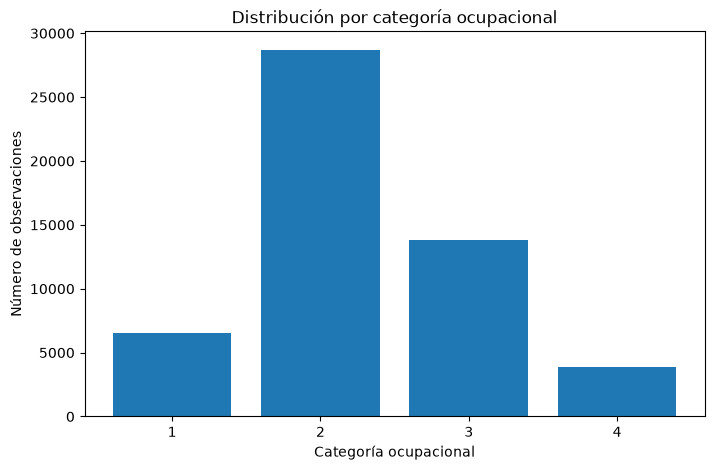

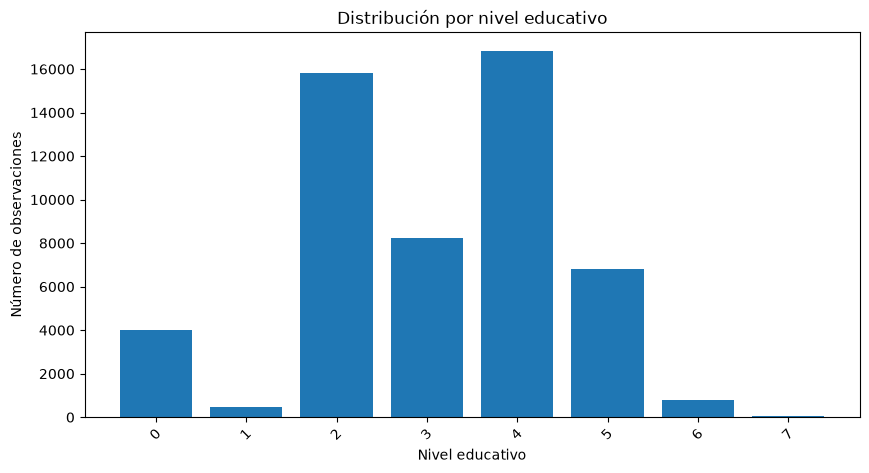

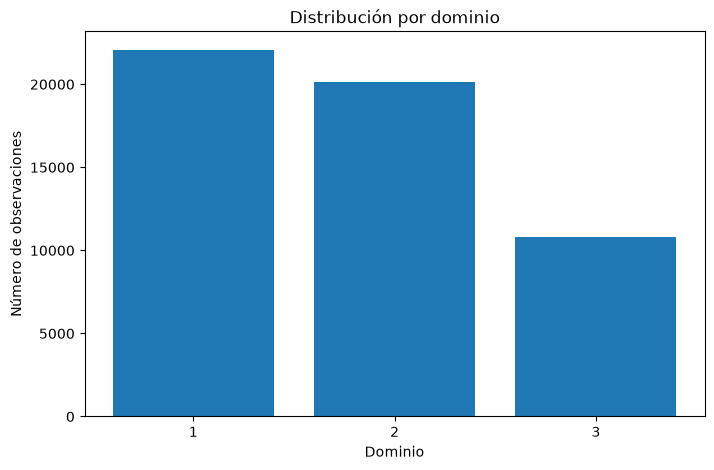

In [53]:
pdf_ocupacion = dist_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_ocupacion["categoria_ocupacional"],
    pdf_ocupacion["count"]
)

plt.title("Distribución por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Número de observaciones")
plt.show()

pdf_educacion = dist_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_educacion["nivel_educativo"],
    pdf_educacion["count"]
)

plt.title("Distribución por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)
plt.show()

pdf_dominio = dist_dominio.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_dominio["dominio"],
    pdf_dominio["count"]
)

plt.title("Distribución por dominio")
plt.xlabel("Dominio")
plt.ylabel("Número de observaciones")
plt.show()

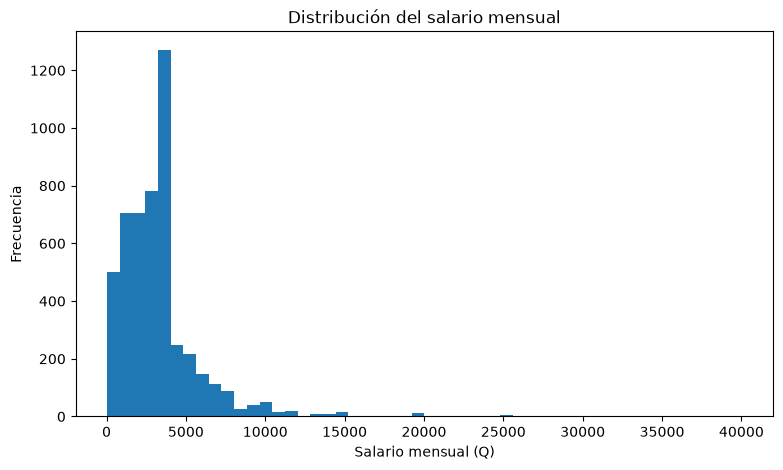

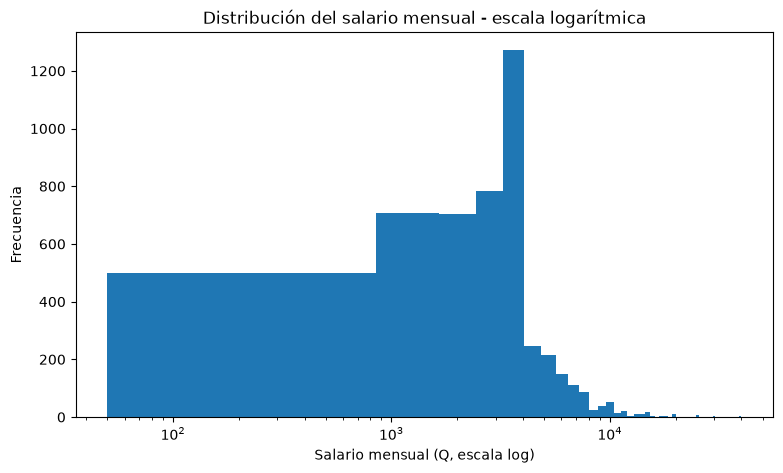

In [54]:
pdf_salario = (
    df_limpio
    .select("salario_mensual")
    .sample(False, 0.15, seed=42)
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.title("Distribución del salario mensual")
plt.xlabel("Salario mensual (Q)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.xscale("log")

plt.title("Distribución del salario mensual - escala logarítmica")
plt.xlabel("Salario mensual (Q, escala log)")
plt.ylabel("Frecuencia")
plt.show()

+---------------+-----+---------------+
|nivel_educativo|    n|salario_mediano|
+---------------+-----+---------------+
|              0| 3995|         1500.0|
|              1|  459|         2160.0|
|              2|15822|         2200.0|
|              3| 8249|         2800.0|
|              4|16851|         3600.0|
|              5| 6818|         5000.0|
|              6|  771|        10000.0|
|              7|   60|        12000.0|
+---------------+-----+---------------+



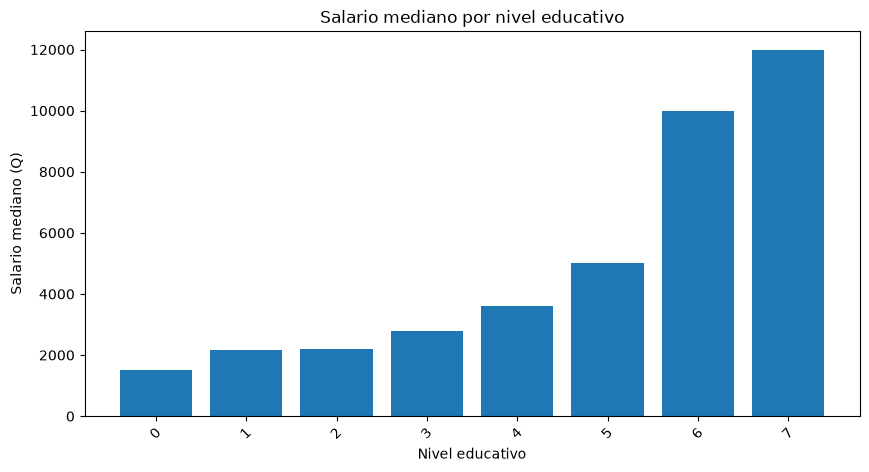

In [55]:
salario_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("nivel_educativo")
)

salario_educacion.show()

pdf_salario_educacion = salario_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_salario_educacion["nivel_educativo"],
    pdf_salario_educacion["salario_mediano"]
)

plt.title("Salario mediano por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario mediano (Q)")
plt.xticks(rotation=45)
plt.show()

+---------------------+-----+---------------+
|categoria_ocupacional|    n|salario_mediano|
+---------------------+-----+---------------+
|                    1| 6575|         5000.0|
|                    2|28702|         3560.0|
|                    3|13842|         1800.0|
|                    4| 3906|         1000.0|
+---------------------+-----+---------------+



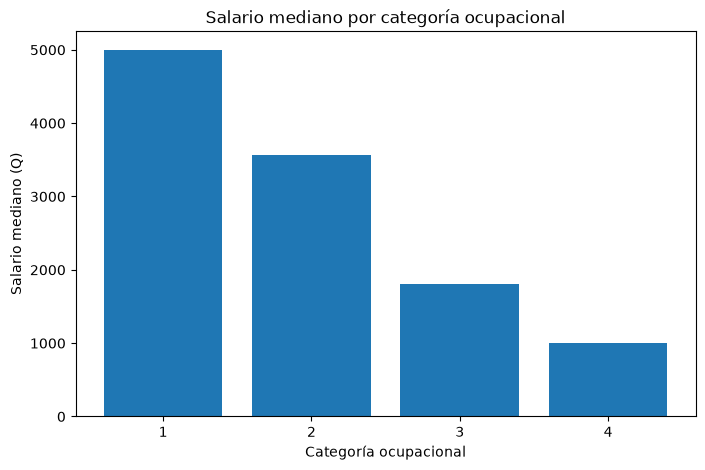

In [56]:
salario_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("categoria_ocupacional")
)

salario_ocupacion.show()

pdf_salario_ocupacion = salario_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_salario_ocupacion["categoria_ocupacional"],
    pdf_salario_ocupacion["salario_mediano"]
)

plt.title("Salario mediano por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Salario mediano (Q)")
plt.show()

In [57]:
resumen_trimestre = (
    df_limpio
    .groupBy(
        "periodo_archivo",
        "trimestre_calendario"
    )
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("trimestre_calendario")
)

resumen_trimestre.show()

+---------------+--------------------+-----+---------------+
|periodo_archivo|trimestre_calendario|    n|salario_mediano|
+---------------+--------------------+-----+---------------+
|         2025T1|                   1|13419|         3000.0|
|         2025T2|                   2|13492|         3000.0|
|         2025T3|                   3|13450|         3200.0|
|         2025T4|                   4|12664|         3200.0|
+---------------+--------------------+-----+---------------+



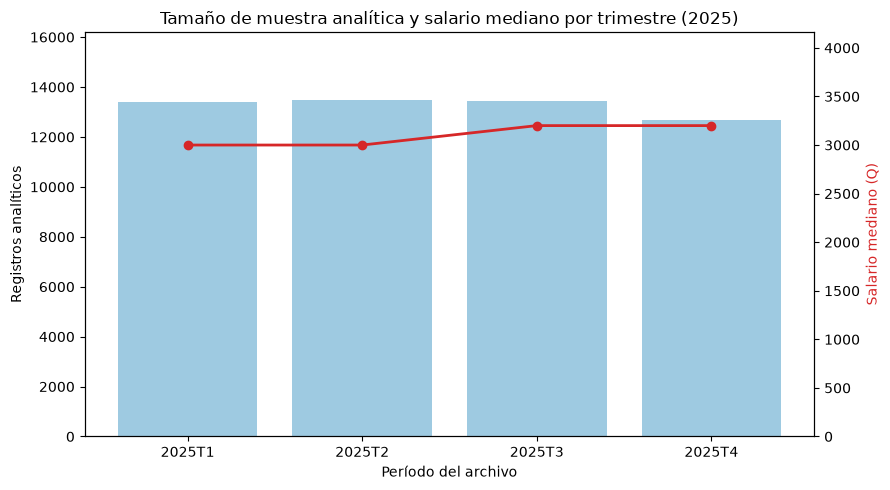

In [58]:
pdf_trimestre = resumen_trimestre.toPandas()

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(pdf_trimestre["periodo_archivo"], pdf_trimestre["n"], color="#9ecae1")
ax1.set_ylabel("Registros analíticos")
ax1.set_xlabel("Período del archivo")
ax1.set_ylim(0, pdf_trimestre["n"].max() * 1.2)

ax2 = ax1.twinx()
ax2.plot(pdf_trimestre["periodo_archivo"], pdf_trimestre["salario_mediano"],
         color="#d62728", marker="o", linewidth=2)
ax2.set_ylabel("Salario mediano (Q)", color="#d62728")
ax2.set_ylim(0, pdf_trimestre["salario_mediano"].max() * 1.3)

plt.title("Tamaño de muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

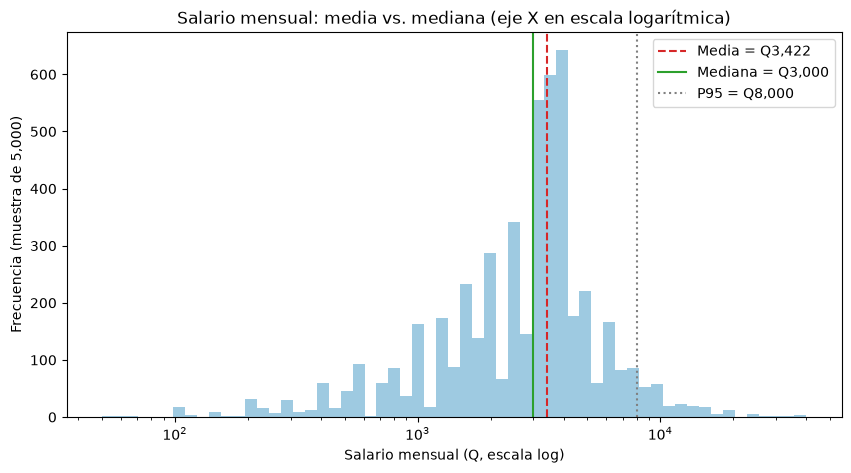

Media y mediana calculadas sobre los 53,025 registros; el histograma usa una muestra.


In [59]:
stats_salario = df_estadisticas.filter(
    F.col("variable") == "salario_mensual"
).first()

plt.figure(figsize=(10, 5))

bins = np.logspace(
    np.log10(pdf_salario["salario_mensual"].min()),
    np.log10(pdf_salario["salario_mensual"].max()),
    60
)

plt.hist(pdf_salario["salario_mensual"], bins=bins, color="#9ecae1")
plt.axvline(stats_salario["media"], color="#d62728", linestyle="--",
            label=f"Media = Q{stats_salario['media']:,.0f}")
plt.axvline(stats_salario["mediana"], color="#2ca02c", linestyle="-",
            label=f"Mediana = Q{stats_salario['mediana']:,.0f}")
plt.axvline(stats_salario["p95"], color="gray", linestyle=":",
            label=f"P95 = Q{stats_salario['p95']:,.0f}")

plt.xscale("log")
plt.title("Salario mensual: media vs. mediana (eje X en escala logarítmica)")
plt.xlabel("Salario mensual (Q, escala log)")
plt.ylabel("Frecuencia (muestra de 5,000)")
plt.legend()
plt.show()

print("Media y mediana calculadas sobre los 53,025 registros; el histograma usa una muestra.")

## Interpretación del análisis exploratorio

La población analítica de 2025 está formada por 53,025 observaciones.

### Distribución de las variables categóricas

La categoría ocupacional 2 es la más frecuente, con 28,702
observaciones, seguida por la categoría 3 con 13,842. Las categorías
1 y 4 presentan 6,575 y 3,906 observaciones, respectivamente. Por lo
tanto, la distribución de los registros entre categorías ocupacionales
no es uniforme.

En nivel educativo, las categorías con mayor cantidad de observaciones
son los niveles 4 (16,851) y 2 (15,822), mientras que los niveles 6 y 7
son considerablemente menos frecuentes.

Respecto al dominio, se observan 22,072 registros en el dominio 1,
20,146 en el dominio 2 y 10,807 en el dominio 3.

### Distribución del salario

El salario mensual presenta una distribución marcadamente asimétrica
hacia la derecha. La mayor concentración de observaciones se encuentra
en los salarios relativamente bajos y medios, mientras existe una cola
hacia valores elevados.

La media salarial es aproximadamente Q3,421.68, mientras que la mediana
es Q3,000. La media superior a la mediana es consistente con la
asimetría positiva observada gráficamente. Además, el percentil 75 es
Q4,000 y el percentil 95 es Q8,000, mientras que el máximo observado
alcanza Q99,000.

Los valores extremos se conservaron en el análisis, de acuerdo con los
criterios establecidos para el laboratorio. La visualización con escala
logarítmica se utilizó únicamente para observar con mayor claridad la
forma de la distribución y no modifica la variable salarial utilizada
en el análisis.

### Edad, antigüedad y jornada laboral

La edad promedio es 35.19 años y la mediana es 33 años. El 50% central
de las observaciones se encuentra aproximadamente entre 24 y 44 años.

La antigüedad presenta una media de 5.56 años y una mediana de 2 años,
lo cual indica también una distribución asimétrica. El percentil 75
corresponde a 7 años y el percentil 95 a 22 años.

Las horas habituales de trabajo presentan una media de 46.31 horas
semanales y una mediana de 45 horas. El 50% central se encuentra entre
40 y 55 horas semanales.

### Salario mediano según educación y categoría ocupacional

Se observa una asociación descriptiva entre nivel educativo y salario
mediano. Los salarios medianos obtenidos para los niveles educativos
0 a 7 fueron Q1,500, Q2,100, Q2,200, Q2,800, Q3,600, Q5,000,
Q10,000 y Q12,000, respectivamente.

Este patrón corresponde a una asociación observada en los datos y no
implica por sí mismo una relación causal entre educación y salario.

También existen diferencias entre categorías ocupacionales. Los
salarios medianos fueron Q5,000 para la categoría 1, Q3,560 para la
categoría 2, Q1,800 para la categoría 3 y Q1,000 para la categoría 4.

### Evolución trimestral

El tamaño de la muestra analítica se mantuvo relativamente estable
durante los primeros tres trimestres: 13,419 observaciones en T1,
13,492 en T2 y 13,450 en T3. En T4 disminuyó a 12,664 observaciones.

El salario mediano fue Q3,000 durante T1 y T2 y Q3,200 durante T3 y T4.
Por tanto, se observa un aumento de Q200 en la mediana entre la primera
y segunda mitad del año dentro de los registros analizados.

## 3. Relaciones entre variables numéricas

In [60]:
variables_corr = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

assembler_corr = VectorAssembler(
    inputCols=variables_corr,
    outputCol="features_corr"
)

df_corr = assembler_corr.transform(df_limpio)

matriz_corr = (
    Correlation
    .corr(
        df_corr,
        "features_corr",
        "pearson"
    )
    .head()[0]
    .toArray()
)

print(matriz_corr)

[[ 1.          0.14724926  0.17957441  0.07566511]
 [ 0.14724926  1.          0.48671276 -0.10537763]
 [ 0.17957441  0.48671276  1.         -0.06225561]
 [ 0.07566511 -0.10537763 -0.06225561  1.        ]]


,Salario,Edad,Antigüedad,Horas semanales
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas semanales,0.076,-0.105,-0.062,1.000


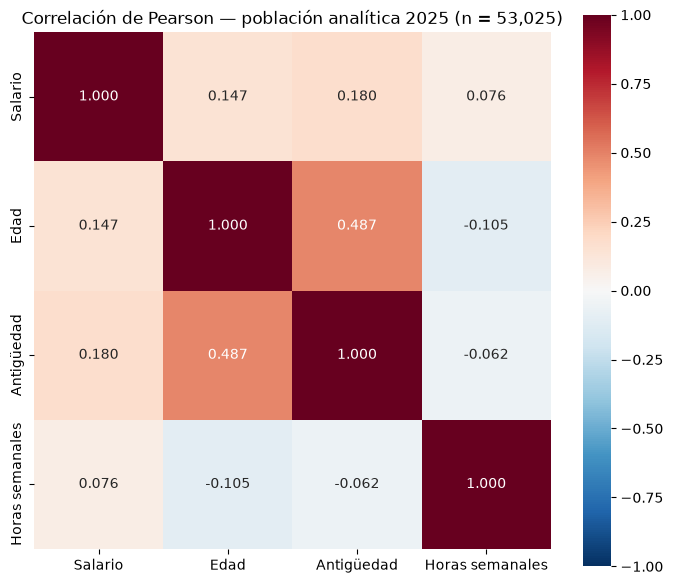

In [61]:
import seaborn as sns

etiquetas_corr = ["Salario", "Edad", "Antigüedad", "Horas semanales"]

pdf_corr = pd.DataFrame(matriz_corr, index=etiquetas_corr, columns=etiquetas_corr)
display(pdf_corr.round(3))

plt.figure(figsize=(7, 6))
sns.heatmap(pdf_corr, annot=True, fmt=".3f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True)
plt.title("Correlación de Pearson — población analítica 2025 (n = 53,025)")
plt.tight_layout()
plt.show()

### Respuestas — Sección 3

**¿Qué variables presentan mayor asociación lineal con el salario?**
La antigüedad (r = 0.180) y la edad (r = 0.147), seguidas de las horas semanales
(r = 0.076). Las tres correlaciones son positivas pero **débiles**. La más alta, elevada al
cuadrado, explica apenas un 3% de la variabilidad del salario. Hay dos razones para esto. Pearson solo
mide relaciones lineales, y el salario puede crecer con la edad y luego estabilizarse. Además,
la cola derecha del salario (hasta Q99,000) pesa mucho en el coeficiente. Como se vio en la
sección 2, el salario se diferencia mucho más por nivel educativo y categoría ocupacional
que por las variables numéricas.

**¿Existe relación entre edad y antigüedad?**
Sí. Es la correlación más fuerte de la matriz: positiva y moderada (r = 0.487). Es lo
esperado, porque la antigüedad no puede superar a la edad y las personas mayores han
tenido más tiempo para acumularla. La relación no es más fuerte porque muchas personas
mayores cambiaron de empleo recientemente y tienen poca antigüedad. Esta asociación implica
cierta redundancia entre ambas variables en el clustering y en la regresión, pero no al nivel
de causar problemas serios de colinealidad.

Las horas semanales tienen una correlación ligeramente negativa con la edad (−0.105) y la
antigüedad (−0.062). Las jornadas más largas se concentran en trabajadores jóvenes y
con menos tiempo en su empleo.

## 4. Segmentación de perfiles mediante KMeans

Se comparan tres conjuntos de variables, todas estandarizadas con `StandardScaler`
(media 0 y desviación 1):

- **A (sin salario):** edad, antigüedad y horas semanales.
- **B (con salario en quetzales):** A + salario mensual.
- **C (con log del salario):** A + log(salario mensual), solo para ver cómo cambia el resultado si se reduce la asimetría.

Para cada conjunto se prueba K = 2, 3, 4 y 5 y se registra el coeficiente de silueta,
la suma de distancias cuadradas intra-cluster (WSSSE) y el tamaño del cluster más pequeño.

In [62]:
from pyspark.ml import Pipeline

CONJUNTOS_CLUSTER = {
    "A_sin_salario": ["edad", "antiguedad", "horas_semanales"],
    "B_con_salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "C_con_log_salario": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}

df_cluster_base = df_2025_final.withColumn(
    "log_salario", F.log(F.col("salario_mensual"))
)

resultados_k = []
modelos_cluster = {}

for nombre, variables in CONJUNTOS_CLUSTER.items():

    pipeline_esc = Pipeline(stages=[
        VectorAssembler(inputCols=variables, outputCol="features_raw"),
        StandardScaler(inputCol="features_raw", outputCol="features",
                       withMean=True, withStd=True),
    ])
    modelo_esc = pipeline_esc.fit(df_cluster_base)
    datos_esc = modelo_esc.transform(df_cluster_base).cache()

    evaluador_sil = ClusteringEvaluator(featuresCol="features",
                                        predictionCol="cluster",
                                        metricName="silhouette")

    for k in [2, 3, 4, 5]:
        kmeans = KMeans(k=k, seed=42, maxIter=50,
                        featuresCol="features", predictionCol="cluster")
        modelo_k = kmeans.fit(datos_esc)
        pred_k = modelo_k.transform(datos_esc)

        tamanos = modelo_k.summary.clusterSizes
        resultados_k.append({
            "conjunto": nombre,
            "k": k,
            "silueta": evaluador_sil.evaluate(pred_k),
            "wssse": modelo_k.summary.trainingCost,
            "cluster_min_pct": 100 * min(tamanos) / sum(tamanos),
        })
        modelos_cluster[(nombre, k)] = (modelo_esc, modelo_k)

    datos_esc.unpersist()

pdf_k = pd.DataFrame(resultados_k)
display(pdf_k.round(4))

,conjunto,k,silueta,wssse,cluster_min_pct
0,A_sin_salario,2,0.5545,106717.3880,27.5417
1,A_sin_salario,3,0.4716,83607.9721,19.0665
2,A_sin_salario,4,0.4763,64438.3407,12.9448
3,A_sin_salario,5,0.4916,56848.5373,4.9316
4,B_con_salario,2,0.5146,157345.5575,27.0269
5,B_con_salario,3,0.4890,135874.2203,5.4239
6,B_con_salario,4,0.4025,113307.7825,4.9090
7,B_con_salario,5,0.4136,94475.7225,3.9415
8,C_con_log_salario,2,0.4112,171215.4850,22.9439
9,C_con_log_salario,3,0.3128,135120.9851,21.8312


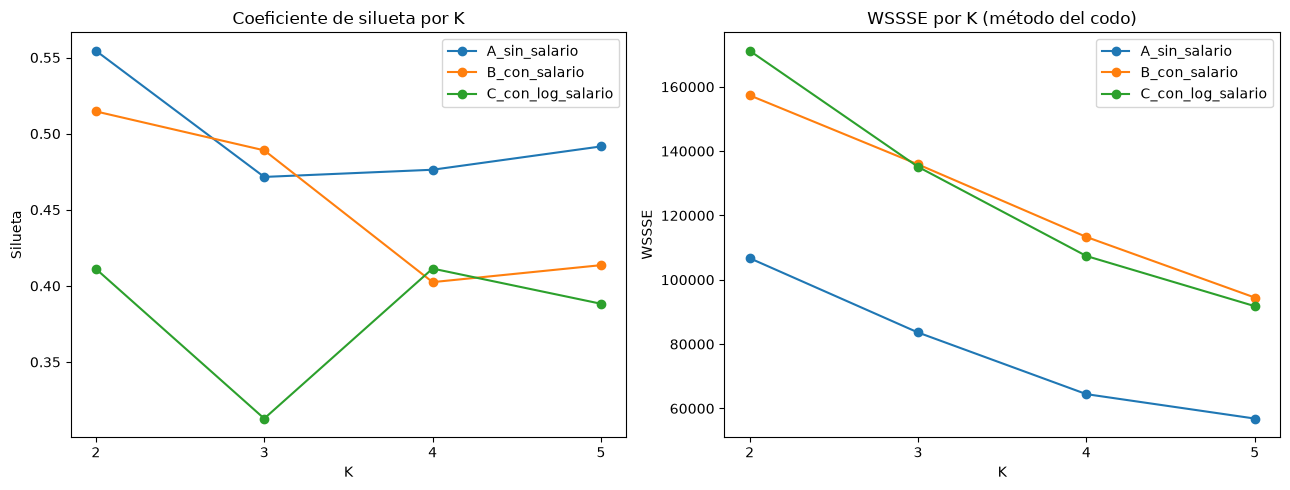

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre, grupo in pdf_k.groupby("conjunto"):
    axes[0].plot(grupo["k"], grupo["silueta"], marker="o", label=nombre)
    axes[1].plot(grupo["k"], grupo["wssse"], marker="o", label=nombre)

axes[0].set_title("Coeficiente de silueta por K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silueta")
axes[0].set_xticks([2, 3, 4, 5])
axes[0].legend()

axes[1].set_title("WSSSE por K (método del codo)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("WSSSE")
axes[1].set_xticks([2, 3, 4, 5])
axes[1].legend()

plt.tight_layout()
plt.show()

### Selección de variables y de K

**¿Vale la pena incluir el salario? No.** Con el salario en quetzales (conjunto B), los
salarios extremos dominan la distancia euclidiana y forman clusters muy pequeños: con K = 3
aparece un grupo de apenas 5.4% de los registros, definido casi solo por ingresos altos.
Con el logaritmo del salario (conjunto C), la silueta empeora para todos los K (0.31–0.41).
Además, el salario es la variable que se busca predecir en la segunda parte. Por eso es más útil
definir los perfiles con características laborales y demográficas y *después* comparar
cuánto gana cada perfil.

**Criterio del grupo para elegir K.** Buscamos una silueta cercana o superior a 0.45, que
todos los clusters tengan al menos el 10% de los registros y que los perfiles se puedan
interpretar con claridad. Con esos criterios elegimos el **conjunto A con K = 4**:

| K | Silueta | WSSSE | Cluster más pequeño | Evaluación |
|---|---|---|---|---|
| 2 | 0.555 | 106,717 | 27.5% | Mejor silueta, pero solo separa jóvenes de mayores; demasiado general |
| 3 | 0.472 | 83,608 | 19.1% | Aceptable |
| **4** | **0.476** | **64,438** | **12.9%** | Silueta similar a K = 3, la WSSSE baja 23% y aparecen 4 perfiles distintos |
| 5 | 0.492 | 56,849 | 4.9% | Crea un cluster demasiado pequeño para describirlo con confianza |